# Shape or mass? Splitting the seed template into its two terms -- `chromatin_od` **and** `tm_score`, 49 ROIs x 3 clicks, post-D11

**Question.** `fill_value_alpha_sweep` established that under `TM_CCOEFF` the filled template's response separates
exactly into a shape term and a mass term, and that deleting the mass term (`alpha = 0`) costs 6 points at
K = 20/30 while doubling it (`alpha = 2`) changes nothing. What it did **not** test is the other half: whether the
**shape** term contributes anything at all. This notebook deletes the shape term instead.

```
R_alpha=1  =  R_0                          +  Dm * sum_kept(I')
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^     ^^^^^^^^^^^^^^^^^^
              SHAPE: does the texture here     MASS: is there this much
              match this particular cell?      extra OD in a footprint this size?
```

`sum_kept(I')` is the image's OD inside the kept rectangle's footprint minus its own local 51 px window mean, so
the mass term is **shape-blind**: it does not care how the density is arranged, only how much of it there is. By
the zero-sum identity `sum_kept(I') = -sum_outside(I')`, it is the same thing as the centre-surround reading --
rewarding excess inside the rectangle and penalising excess outside it are one term, not two.

**The arms are an exact decomposition, not three unrelated templates.** Writing `m_k`, `m_o` for the means inside
and outside the kept rectangle and `Dm = m_k - m_o`:

| arm | template pixels | keeps | response |
|---|---|---|---|
| `default_51` | the raw 51x51 `hematoxylin_od` window on the click | everything | the incumbent |
| `fill_alpha_0` | the window, outside the rectangle set to `m_k` | **shape only** | `R_0` |
| `mass_only` | flat `m_k` inside the rectangle, flat `m_o` outside | **mass only** | `Dm * sum_kept(I')` |
| `fill_alpha_1` | the window, outside the rectangle set to `m_o` -- the recorded `hem_rect_fill` | shape + mass | `R_0 + Dm * sum_kept(I')` |

so that, exactly and verifiably (Gate 6 checks both to float32 tolerance on real windows):

```
R(fill_alpha_1)  ==  R(fill_alpha_0)  +  R(mass_only)
R(mass_only)     ==  Dm * sum_kept(I')
```

`mass_only` is a **box filter**: two flat levels, carrying no information about the clicked cell except the size
and position of its rectangle. If it matches `fill_alpha_1`, then the clicked cell's appearance contributes
nothing to candidate generation and the click is supplying a footprint, not a template.

## Both ranking axes, from the same detections

`chromatin_od` ranks by integrated OD over a 51 px window, and the mass term *is* integrated OD over the kept
footprint. Those are nearly the same statistic, so a `mass_only` arm scored only at `chromatin_od` would be
uninterpretable -- it would generate candidates pre-aligned with the axis it is then ranked on. **This is why the
`tm_score` axis is not optional here.**

Both rankings are produced from the **identical detection list**: the template search, peak extraction, NMS and
D11 blanking all run once per (click, arm), and the two axes differ only in the final sort. So the axis comparison
is exact by construction, not an approximation, and it costs one extra sort rather than a second search. Gate 7
asserts that the two rankings are permutations of the same detection set on every run.

## Identical in all four arms

Only the template's pixel values differ. These are the same:
- the 147 clicks, inherited from the 49-ROI joint gate, in the recorded order;
- window position (centred on the click) and template size (51 px) -- so `blank_seed_square` blanks the **same**
  51x51 square in every arm, carrying none of the base-size confound `bbox_refinement_three_way` had;
- the kept rectangle, asserted equal to the recorded `hem_rect_fill` rectangle on every click, so every arm
  describes the **same** footprint and the arms differ only in what they do with it;
- search image (`hematoxylin_od`, D11-blanked then replicate-padded by 25 px);
- peak, NMS and seed settings (`PEAK_MIN_DISTANCE` 7, `DEEP_FLOOR_Z` -1.5, `MAX_PEAKS` 100,
  NMS radius = match radius = 7.5 um, `blank_seed_square` at the click, base_size 51);
- the `chromatin_od` window (51 px), scored against the **unblanked** channel;
- scoring (greedy centre-distance match at 7.5 um, the click's own annotation removed from the ground truth),
  and a fixed K, since each arm's peak threshold comes from its own response map and list lengths can differ.

## Gates, all before any statistic is read

1. **Harness fidelity (pre-D11, subset).** On the first 2 ROIs x 3 clicks, the inlined pipeline run in pre-D11
   mode must reproduce the recorded `bbox3way` `default_51` and `hemrectfill` `hem_rect_fill` runs bit for bit.
2. **Production-path equivalence (post-D11, subset).** The inlined pipeline with the `default_51` template must
   equal `production.run_production_pipeline` row for row, at **both** `rank_key` values.
3. **Cross-notebook parity (full run).** Three of the four arms are already recorded at `chromatin_od` by
   `fill_value_alpha_sweep`. `default_51`, `fill_alpha_0` and `fill_alpha_1` must each reproduce that run on all
   147 clicks -- counts, TP@10/20/30, template SHA-1 and the top-30 rank/cx/cy/bucket/matched_ann_id/score/od.
   Only `mass_only` and the `tm_score` axis are new measurements.
4. **Templates (full run).** `default_51` and `fill_alpha_1` SHA-1s match the recorded ones, the rectangle matches
   the recorded one, `fill_alpha_1`'s fill equals the recorded `fill_value`, and the four templates are pairwise
   distinct on every click.
5. **`mass_only` really is shape-free (full run).** Its template takes exactly two distinct values, one on the
   rectangle and one off it, and its mean-centred `T'` is constant on each region.
6. **The decomposition (subset).** `R(fill_alpha_1) == R(fill_alpha_0) + R(mass_only)` and
   `R(mass_only) == Dm * sum_kept(I')`, both to float32 tolerance, on real windows.
7. **The two axes share one detection set (full run).** For every run, the `chromatin_od` and `tm_score` rankings
   must be permutations of the same (cx, cy, score) rows.
8. **The arms differ downstream (full run, report-only).** `MAX_PEAKS` binds at 100 and the ranker re-sorts
   afterwards, so different templates could still wash out to identical lists. Top-30 overlap is reported per arm
   pair and per axis, so a wash-out is visible rather than silent.

## Comparisons, fixed before the run

Every delta is `a - b`, the unit is the ROI (49), a ROI's delta at K is its TP@K summed over its 3 clicks, and
**each ranking axis is its own family** -- they are two different outcomes, not two tests of one hypothesis.

Per axis:
- **Primary (3 tests, Holm within):** `mass_only - fill_alpha_1`. Does deleting the shape term cost anything?
- **Secondary, the decomposition (6 tests, Holm within):** `mass_only - fill_alpha_0` (mass against shape, head
  to head) and `fill_alpha_0 - fill_alpha_1` (deleting mass -- at `chromatin_od` this must reproduce the recorded
  sweep exactly, and at `tm_score` it is new).
- **Secondary, against the incumbent (6 tests, Holm within):** `mass_only - default_51` and
  `fill_alpha_1 - default_51`.

Per pair and K: the pooled precision delta with a cluster bootstrap 95% CI over ROIs (`BOOT_SEED` 20260917 and the
same ROI order as every earlier run, asserted), a t interval over the ROI-level deltas, ROI-level W/L/T,
`n_nonzero` and `min_attainable_p`, an exact sign-flip p by convolution, Holm within the family, and the D5 bar
(bootstrap CI excludes 0 **and** a majority of all 49 ROIs move in the delta's direction).

**Reading rules, fixed before the run.** Applied to the bootstrap CI of each delta at each K.
- **CI excludes 0, delta < 0:** `a` has lower precision than `b`.
- **CI excludes 0, delta > 0:** `a` has higher precision than `b`.
- **CI includes 0:** no difference detected. The CI is quoted as the bound. No equivalence is claimed.

Ties bound what can be shown: precision@K moves in steps of `1/(3K)` per ROI, the exact sign-flip p cannot fall
below `2 ** (1 - n_nonzero)`, and any row whose Holm-adjusted floor exceeds 0.05 is flagged as bounding nothing.

**What each outcome would mean, written down now so it cannot be chosen afterwards.**
- *`mass_only` ties `fill_alpha_1` on **both** axes:* the clicked cell's appearance contributes nothing to
  candidate generation. The click supplies a footprint and a location, not a template, and every question about
  refining the template's pixels -- keep-region shape, hybrid rectangles, margins -- is moot at `chromatin_od`
  and at `tm_score` alike.
- *`mass_only` ties at `chromatin_od` but loses at `tm_score`:* the tie is the ranker-alignment confound, not a
  real equivalence. The shape term does work that `chromatin_od` re-ranking happens to hide. Read `tm_score` as
  the answer and treat the `chromatin_od` result as contaminated.
- *`mass_only` loses on both axes:* the seed's appearance is doing real work; the 6-point `alpha = 0` deficit was
  not the whole story, and both terms are needed.
- *`mass_only` **wins** anywhere:* the seed's own texture is actively harmful -- it overfits the clicked cell.
  That would argue for a generic footprint detector over a click-derived template, which is a product-level
  finding, not a tuning one.

## Caveats

- The 147 clicks are inherited from the 49-ROI joint gate, so every click is one where both Otsu gates accept.
  A rectangle must exist for any of these arms to be defined, so conditioning on the hem gate is intrinsic;
  conditioning on the *gray* gate is not, and is inherited baggage.
- One keep-region (the tight `tighten_box_otsu` rectangle).
- `mass_only` still takes its footprint from the clicked cell. This notebook does **not** test whether a
  footprint that ignores the click entirely would do as well; that is the next arm, not this one.
- `Dm` varies per click, so `mass_only`'s response scale varies per click. That is immaterial: the peak threshold
  is `median + z * MAD` of each arm's own map, so a global scale on the response cancels.
- **Power.** ROI-level bootstrap CIs at K = 30 run about +/-1 to 2 points on these clicks. Effects smaller than
  that will not resolve, and no equivalence is claimed -- a tie is reported as the CI's bound.

In [1]:
import gc
import hashlib
import itertools
import math
import os
import sys
import time
import types

import cv2
import numpy as np
import pandas as pd
from fractions import Fraction
from scipy import stats as sps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the recorded runs used'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
assert (tm.BASE_SIZE, tm.PATCH_SIZE) == (51, 73), 'the template and patch sizes this notebook hard-codes'
assert prod.OD_WINDOW // 2 == 25, 'the replicate pad this notebook hard-codes is 25 px'
assert hasattr(tm, 'blank_seed_square'), 'D11 has not been applied: template_match.blank_seed_square is missing'
assert not hasattr(prod, 'SELF_HIT_RADIUS'), 'production.SELF_HIT_RADIUS still exists, so this is not post-D11 code'
assert set(prod.AXES) == {'tm_score', 'chromatin_od'}, f'production.AXES changed: {prod.AXES}'

SMOKE_ROIS = None            # None = all 49 ROIs; a smoke run names a few ROI file names
PRE_D11_SELF_HIT_RADIUS = 5.0  # the constant D11 deleted, kept only to replay the pre-D11 gate
PAD = prod.OD_WINDOW // 2      # 25
BASE_SIZE = tm.BASE_SIZE       # 51

ARMS = ('default_51', 'fill_alpha_0', 'mass_only', 'fill_alpha_1')
ARM_TERMS = {'default_51': 'untouched window', 'fill_alpha_0': 'shape only', 'mass_only': 'mass only', 'fill_alpha_1': 'shape + mass'}
RECORDED_ARMS = ('default_51', 'fill_alpha_0', 'fill_alpha_1')   # already measured at chromatin_od by fill_value_alpha_sweep
NEW_ARM = 'mass_only'
AXES = ('chromatin_od', 'tm_score')
AXIS_KEY = {'chromatin_od': 'od', 'tm_score': 'score'}            # production.AXES, restated so drift is visible
assert AXIS_KEY == prod.AXES, f'this notebook and production.AXES disagree: {AXIS_KEY} vs {prod.AXES}'

FAMILY_PAIRS = {
    'primary_3': ((NEW_ARM, 'fill_alpha_1'),),
    'secondary_decomposition_6': ((NEW_ARM, 'fill_alpha_0'), ('fill_alpha_0', 'fill_alpha_1')),
    'secondary_vs_default_6': ((NEW_ARM, 'default_51'), ('fill_alpha_1', 'default_51')),
}
PAIRS = tuple(pair for pairs in FAMILY_PAIRS.values() for pair in pairs)
PAIR_FAMILY = {f'{a} - {b}': fam for fam, pairs in FAMILY_PAIRS.items() for a, b in pairs}
assert len(PAIR_FAMILY) == len(PAIRS), 'a pair appears in two families'
REPRO_PAIR = 'fill_alpha_0 - fill_alpha_1'  # at chromatin_od this must equal the recorded sweep exactly

BUDGETS = (10, 20, 30)
SEED_INDICES = (0, 1, 2)
N_BOOT = 10_000
BOOT_SEED = 20260917  # every earlier run's seed; with the same ROI order the resampled ROI sets are the same ones
B3 = '../results/precision_at_k_49roi_3seed_chromatin_bbox3way'
B3P = f'{B3}_postD11'
HRF = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill'
FA = '../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11'
SUBSET_DIRS = {'original_14': '../images/extra_valid', 'testing_35': '../images/extra_valid/testing_set'}
INSPECT_ROI = '300.tiff'
N_GATE_ROIS = 2

SUFFIX = '' if SMOKE_ROIS is None else '_smoke'
OUT_STEM = f'../results/precision_at_k_49roi_3seed_shapemass_postD11{SUFFIX}'
OUT = {name: f'{OUT_STEM}_{name}.csv' for name in ('clicks', 'per_run', 'top30', 'per_roi', 'delta_per_roi', 'delta_stats', 'overlap', 'verification')}
FIG_PATHS = {name: f'shapemass_{name}{SUFFIX}.png' for name in ('inspect_templates', 'precision')}
RECORDED_STEMS = (B3, B3P, HRF, f'{HRF}1um', FA, '../results/precision_at_k_14roi_')
assert not any(p.startswith(stem) for p in OUT.values() for stem in RECORDED_STEMS), 'an output path would overwrite a recorded run'

# Okabe-Ito, the published colourblind-safe qualitative set; fixed order, one hue per arm, never cycled.
ARM_COLOR = {'default_51': '#666666', 'fill_alpha_0': '#0072B2', 'mass_only': '#D55E00', 'fill_alpha_1': '#E69F00'}

print(f"\narms {ARMS}; new arm {NEW_ARM!r}; ranking axes {AXES}; K = {BUDGETS}; cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED}); smoke ROIs = {SMOKE_ROIS}")
for fam, pairs in FAMILY_PAIRS.items():
    print(f"  {fam} (per axis): {[f'{a} - {b}' for a, b in pairs]}")
print('outputs:', *OUT.values(), *FIG_PATHS.values(), sep='\n  ')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

arms ('default_51', 'fill_alpha_0', 'mass_only', 'fill_alpha_1'); new arm 'mass_only'; ranking axes ('chromatin_od', 'tm_score'); K = (10, 20, 30); cluster bootstrap B = 10000 (seed 20260917); smoke ROIs = None
  primary_3 (per axis): ['mass_only - fill_alpha_1']
  secondary_decomposition_6 (per axis): ['mass_only - fill_alpha_0', 'fill_alpha_0 - fill_alpha_1']
  secondary_vs_default_6 (per axis): ['mass_only - default_51', 'fill_alpha_1 - default_51']
outputs:
  ../results/precision_at_k_49roi_3seed_shapemass_postD11_clicks.csv
  ../results/precision_at_k_49roi_3seed_shapemass_p

In [2]:
B3P_RUN = pd.read_csv(f'{B3P}_per_run.csv', float_precision='round_trip')
B3_RUN = pd.read_csv(f'{B3}_per_run.csv', float_precision='round_trip')
B3_TOP = pd.read_csv(f'{B3}_top30.csv', float_precision='round_trip')
HRF_RUN = pd.read_csv(f'{HRF}_per_run.csv', float_precision='round_trip')
HRF_TOP = pd.read_csv(f'{HRF}_top30.csv', float_precision='round_trip')
HRF_CLICKS = pd.read_csv(f'{HRF}_clicks.csv', float_precision='round_trip')
FA_RUN = pd.read_csv(f'{FA}_per_run.csv', float_precision='round_trip')
FA_TOP = pd.read_csv(f'{FA}_top30.csv', float_precision='round_trip')
FA_DELTA = pd.read_csv(f'{FA}_delta_per_roi.csv', float_precision='round_trip')
assert (len(B3P_RUN), len(FA_RUN), len(FA_TOP), len(HRF_RUN)) == (441, 735, 22050, 294), 'a recorded input does not have its expected row count'
assert set(FA_RUN['condition']) >= set(RECORDED_ARMS), f'the recorded sweep is missing an arm this notebook re-runs: {set(RECORDED_ARMS) - set(FA_RUN["condition"])}'

# the parity target for the three recorded arms, at chromatin_od
FA_REF = FA_RUN[FA_RUN['condition'].isin(RECORDED_ARMS)].set_index(['file_name', 'seed_index', 'condition']).sort_index()
FA_REF_TOP = {key: g for key, g in FA_TOP[FA_TOP['condition'].isin(RECORDED_ARMS)].groupby(['file_name', 'seed_index', 'condition'])}
assert FA_REF.index.is_unique and len(FA_REF) == 3 * 147 and len(FA_REF_TOP) == 3 * 147, 'the recorded sweep is not one row and one top-30 list per click per arm'
assert all(len(g) == 30 for g in FA_REF_TOP.values()), 'a recorded top-30 list does not have 30 rows'

# pre-D11 references, used only by the harness-fidelity gate
PRE_RUN = pd.concat([B3_RUN[B3_RUN['condition'] == 'default_51'], HRF_RUN[HRF_RUN['condition'] == 'hem_rect_fill']]).set_index(['file_name', 'seed_index', 'condition']).sort_index()
PRE_TOP = {key: g for key, g in pd.concat([B3_TOP[B3_TOP['condition'] == 'default_51'], HRF_TOP[HRF_TOP['condition'] == 'hem_rect_fill']]).groupby(['file_name', 'seed_index', 'condition'])}
PRE_ARM_OF = {'default_51': 'default_51', 'fill_alpha_1': 'hem_rect_fill'}

CLICKS = B3P_RUN[B3P_RUN['condition'] == 'default_51'].reset_index(drop=True)
rect_rec = HRF_CLICKS[['file_name', 'seed_index', 'rect_y0', 'rect_y1', 'rect_x0', 'rect_x1', 'fill_value', 'n_filled_px']].rename(columns={'rect_y0': 'rec_y0', 'rect_y1': 'rec_y1', 'rect_x0': 'rec_x0', 'rect_x1': 'rec_x1', 'fill_value': 'rec_fill_value', 'n_filled_px': 'rec_n_filled_px'})
alpha1_sha = FA_RUN.loc[FA_RUN['condition'] == 'fill_alpha_1', ['file_name', 'seed_index', 'tpl_sha1']].rename(columns={'tpl_sha1': 'rec_alpha1_sha1'})
click_keys = list(zip(CLICKS['file_name'], CLICKS['seed_index']))
CLICKS = CLICKS.merge(rect_rec, on=['file_name', 'seed_index'], how='left', validate='one_to_one').merge(alpha1_sha, on=['file_name', 'seed_index'], how='left', validate='one_to_one')
assert list(zip(CLICKS['file_name'], CLICKS['seed_index'])) == click_keys, 'a merge changed the click rows or their order'
assert CLICKS[['rec_y0', 'rec_y1', 'rec_x0', 'rec_x1', 'rec_fill_value', 'rec_alpha1_sha1']].notna().all().all(), 'a click has no recorded fill geometry'
assert list(pd.unique(CLICKS['file_name'])) == list(pd.unique(FA_RUN['file_name'])) == list(pd.unique(HRF_RUN['file_name'])), 'the ROI order differs from an earlier run, so reusing BOOT_SEED would not resample the same ROI sets'

ROI_ORDER = [fn for fn in pd.unique(CLICKS['file_name']) if SMOKE_ROIS is None or fn in SMOKE_ROIS]
assert SMOKE_ROIS is None or sorted(ROI_ORDER) == sorted(SMOKE_ROIS), f'smoke ROIs not found: {SMOKE_ROIS}'
N_ROIS = len(ROI_ORDER)
CLICKS = CLICKS[CLICKS['file_name'].isin(ROI_ORDER)].reset_index(drop=True)
GATE_ROIS = ROI_ORDER[:N_GATE_ROIS]

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
for r in CLICKS.itertuples():
    match = annotations[(annotations['ann_id'] == r.seed_ann_id) & (annotations['file_name'] == r.file_name)]
    assert len(match) == 1, f'{r.file_name} s{r.seed_index}: {len(match)} annotation rows for ann_id {r.seed_ann_id}'
    assert match['category_id'].iat[0] == ds.MITOTIC and match['cx'].iat[0] == r.click_cx and match['cy'].iat[0] == r.click_cy, f'{r.file_name} s{r.seed_index}: ann_id {r.seed_ann_id} is not a mitotic figure at the recorded click'
assert len(CLICKS) == 3 * N_ROIS, f'{len(CLICKS)} clicks, expected {3 * N_ROIS}'
assert SMOKE_ROIS is not None or N_ROIS == 49, f'full run has {N_ROIS} ROIs, expected 49'

print(f"{len(CLICKS)} clicks on {N_ROIS} ROIs; ROI order matches every earlier run, so BOOT_SEED reuse resamples the same ROI sets")
print(f"{len(RECORDED_ARMS)} of {len(ARMS)} arms are already recorded at chromatin_od and must reproduce it; new: {NEW_ARM!r} and the {AXES[1]!r} axis")
print(f"gate ROIs: {GATE_ROIS}")

147 clicks on 49 ROIs; ROI order matches every earlier run, so BOOT_SEED reuse resamples the same ROI sets
3 of 4 arms are already recorded at chromatin_od and must reproduce it; new: 'mass_only' and the 'tm_score' axis
gate ROIs: ['300.tiff', '301.tiff']


In [3]:
def cut_window(hem, cx, cy):
    """
        The 51 px template production cuts for a click, and the identical Otsu window, checked against each other.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns np.ndarray: the 51x51 float32 template, exactly as build_augmentations produces it.
    """
    patch = tm.read_padded_patch(hem, cx, cy, tm.PATCH_SIZE)
    assert patch is not None, f'({cx}, {cy}): the 73 px patch is not readable'
    templates, _ = tm.build_augmentations(patch, BASE_SIZE, (1.0,), 1, (False,))
    T = templates[0]
    assert T.shape == (BASE_SIZE, BASE_SIZE) and T.dtype == np.float32, f'({cx}, {cy}): template is {T.shape} {T.dtype}'
    W = tm.read_padded_patch(hem, cx, cy, BASE_SIZE)
    assert np.array_equal(W, T), f'({cx}, {cy}): the Otsu window and the template are not the same pixels'
    return T


def cut_templates(hem, cx, cy):
    """
        The four arms' templates for one click, all built from the same kept rectangle so the arms differ only in what they keep of it.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns dict: templates (arm -> 51x51 float32), rect, outside, m_kept, m_outside, delta_m, w_shape, n_kept, n_filled.
    """
    T = cut_window(hem, cx, cy)
    rect = ss.tighten_box_otsu(T)
    assert rect is not None, f'({cx}, {cy}): tighten_box_otsu refused the window'
    y0, y1, x0, x1 = rect
    outside = np.ones((BASE_SIZE, BASE_SIZE), bool)
    outside[y0:y1, x0:x1] = False
    assert outside.any(), f'rectangle {rect} covers the whole window, so nothing is filled'
    m_kept = float(T[~outside].astype(np.float64).mean())
    m_outside = float(T[outside].astype(np.float64).mean())
    n_kept = int((~outside).sum())
    w_shape = float(np.abs(T[~outside].astype(np.float64) - m_kept).sum())
    assert w_shape > 0, f'({cx}, {cy}): the kept region is perfectly flat, so the shape term is zero'

    shape_only = T.copy()                        # outside -> m_kept: the ring's T' is 0, leaving R_0 alone
    shape_only[outside] = np.float32(m_kept)
    shape_and_mass = T.copy()                    # outside -> m_outside: the recorded hem_rect_fill template
    shape_and_mass[outside] = np.float32(m_outside)
    mass_only = np.full((BASE_SIZE, BASE_SIZE), np.float32(m_outside))  # two flat levels: no texture anywhere
    mass_only[~outside] = np.float32(m_kept)

    templates = {'default_51': T, 'fill_alpha_0': shape_only, 'mass_only': mass_only, 'fill_alpha_1': shape_and_mass}
    for arm, F in templates.items():
        assert F.dtype == np.float32 and F.shape == (BASE_SIZE, BASE_SIZE), f'{arm}: template is {F.dtype} {F.shape}'
        templates[arm] = np.ascontiguousarray(F, dtype=np.float32)
    assert np.array_equal(templates['fill_alpha_0'][y0:y1, x0:x1], T[y0:y1, x0:x1]) and np.array_equal(templates['fill_alpha_1'][y0:y1, x0:x1], T[y0:y1, x0:x1]), 'a fill changed a kept pixel'
    assert len(np.unique(templates['mass_only'])) == 2, f"mass_only takes {len(np.unique(templates['mass_only']))} distinct values, not 2"
    return dict(templates=templates, rect=rect, outside=outside, m_kept=m_kept, m_outside=m_outside, delta_m=m_kept - m_outside, w_shape=w_shape, n_kept=n_kept, n_filled=int(outside.sum()))


def template_sha1(T):
    """
        SHA-1 of a template's float32 bytes, the digest the recorded runs store as tpl_sha1.

        T (np.ndarray): the 51x51 float32 template.

        Returns str: the hex digest.
    """
    return hashlib.sha1(np.ascontiguousarray(T, dtype=np.float32).tobytes()).hexdigest()


def region_constant(F, outside):
    """
        The two values a shape-free template takes, and how far each region departs from being constant.

        F (np.ndarray): the 51x51 float32 template.
        outside (np.ndarray): boolean mask of the pixels off the kept rectangle.

        Returns tuple[float, float, float]: the inside value, the outside value, and the largest within-region spread.
    """
    inside_v, outside_v = F[~outside], F[outside]
    return float(inside_v.flat[0]), float(outside_v.flat[0]), float(max(inside_v.max() - inside_v.min(), outside_v.max() - outside_v.min()))

In [4]:
def padded(channel, pad=PAD):
    """
        A channel replicate-padded on every side, the way find_and_suppress pads when border_pad is set.

        channel (np.ndarray): the channel to pad.
        pad (int): pixels added on every side.

        Returns np.ndarray: the padded channel.
    """
    return cv2.copyMakeBorder(channel, pad, pad, pad, pad, borderType=cv2.BORDER_REPLICATE)


def blanked_search(hem, cx, cy, base_size=BASE_SIZE):
    """
        D11's search channel for one click: the seed's own template footprint blanked from a copy, then padded.

        hem (np.ndarray): this ROI's hematoxylin_od channel; never mutated.
        cx (float): template centre x, the click.
        cy (float): template centre y, the click.
        base_size (int): the blanked square's side, 51 for every arm here.

        Returns tuple[np.ndarray, int]: the blanked, padded search channel and the number of pixels blanked.
    """
    search, n_blanked = tm.blank_seed_square(hem, cx, cy, base_size)
    return padded(search), int(n_blanked)


def search_once(match_padded, od_padded, shape, template, cx, cy, nms_radius, self_hit_radius=None):
    """
        One template's search over the ROI, stopping before the ranking sort so both axes can rank the SAME detections.

        match_padded (np.ndarray): the search channel to correlate against, padded by PAD; D11-blanked for the real run, unblanked for the pre-D11 gate.
        od_padded (np.ndarray): the UNBLANKED hematoxylin_od channel padded by PAD, used only for chromatin_od scoring.
        shape (tuple): the unpadded channel's (height, width).
        template (np.ndarray): the 51x51 float32 template.
        cx (float): click x, the template centre and the pre-D11 self-hit centre.
        cy (float): click y, the template centre and the pre-D11 self-hit centre.
        nms_radius (float): this ROI's NMS radius in pixels, evaluate.radius_px(mpp).
        self_hit_radius (float or None): None runs the post-D11 path with no self-hit filter; a radius replays the pre-D11 post-NMS filter.

        Returns tuple[pd.DataFrame, dict]: unranked detections (cx, cy, score, od) and the counts n_peaks, n_detections, n_self_hits.
    """
    h, w = shape
    fused_p, best_p, valid_p = tm.fused_response(match_padded, [template], False, method=prod.TM_METHOD)
    fused = fused_p[PAD:PAD + h, PAD:PAD + w]
    valid = valid_p[PAD:PAD + h, PAD:PAD + w]
    assert valid.all(), 'the 25 px pad left part of the ROI unreachable'
    med, mad = tm.robust_stats(fused, valid)
    threshold = med + prod.DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, prod.PEAK_MIN_DISTANCE, threshold, prod.MAX_PEAKS)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    n_self_hits = 0
    if self_hit_radius is not None:
        self_hit = np.hypot(centers[:, 0] - float(cx), centers[:, 1] - float(cy)) <= self_hit_radius
        n_self_hits = int(self_hit.sum())
        centers, scores = centers[~self_hit], scores[~self_hit]
    det = pd.DataFrame({'rank': np.arange(len(centers)), 'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    shifted = det.assign(cx=det['cx'] + PAD, cy=det['cy'] + PAD)
    det = det.assign(od=cm.score_detections(shifted, od_padded, window=prod.OD_WINDOW)['od'].to_numpy())
    return det, {'n_peaks': n_peaks, 'n_detections': len(det), 'n_self_hits': n_self_hits}


def rank_by(det, rank_key):
    """
        One ranking axis applied to a detection list, in run_production_pipeline's own sort order.

        det (pd.DataFrame): the unranked detections from search_once.
        rank_key (str): "chromatin_od" or "tm_score".

        Returns pd.DataFrame: the detections ranked best-first, with rank reassigned.
    """
    out = det.sort_values(AXIS_KEY[rank_key], ascending=False, na_position='last', kind='mergesort').reset_index(drop=True)
    return out.assign(rank=np.arange(len(out)))


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def parity_gate(tag, out, info, tp, ref_run, ref_top, count_cols):
    """
        Assert that a re-run arm reproduces a recorded run, and count the top-30 od values that match bit for bit.

        tag (str): names the click and arm in assertion messages.
        out (pd.DataFrame): the re-run's scored detections, ranked.
        info (dict): the re-run's counts, keyed as count_cols names them.
        tp (dict): the re-run's K -> true positives.
        ref_run (pd.Series): the recorded per_run row for this click and arm.
        ref_top (pd.DataFrame): the recorded top-30 rows for this click and arm.
        count_cols (tuple[str]): info keys compared against identically-named recorded columns.

        Returns int: the number of top-30 od values equal to the recorded ones bit for bit.
    """
    for c in count_cols:
        assert int(info[c]) == int(ref_run[c]), f'{tag}: {c} {info[c]} != recorded {int(ref_run[c])}'
    for k in BUDGETS:
        assert tp[k] == int(ref_run[f'tp_at_{k}']), f"{tag}: TP@{k} {tp[k]} != recorded {int(ref_run[f'tp_at_{k}'])}"
    ref, top = ref_top.sort_values('rank'), out.head(30)
    assert len(top) == len(ref) == 30, f'{tag}: {len(top)} rows vs {len(ref)} recorded'
    for c in ('rank', 'cx', 'cy', 'bucket', 'matched_ann_id'):
        assert np.array_equal(top[c].to_numpy(), ref[c].to_numpy()), f'{tag}: top-30 {c} differs from the recorded list'
    # score is stored at float32 repr in the recorded CSVs, so it is compared after a float32 cast; od is stored at full precision
    assert np.array_equal(top['score'].to_numpy(), ref['score'].to_numpy().astype(np.float32)), f'{tag}: top-30 float32 score differs from the recorded list'
    assert np.isclose(top['od'].to_numpy(), ref['od'].to_numpy(), rtol=1e-12, atol=0).all(), f'{tag}: top-30 od differs from the recorded list beyond rtol 1e-12'
    return int((top['od'].to_numpy() == ref['od'].to_numpy()).sum())


def same_detection_set(a, b):
    """
        Gate 7's test that two rankings are permutations of one detection set, not two different searches.

        a (pd.DataFrame): one axis's ranked detections.
        b (pd.DataFrame): the other axis's ranked detections.

        Returns bool: True when both hold the same (cx, cy, score, od) rows in some order.
    """
    cols = ['cx', 'cy', 'score', 'od']
    if len(a) != len(b):
        return False
    ka = a[cols].sort_values(cols, kind='mergesort').to_numpy()
    kb = b[cols].sort_values(cols, kind='mergesort').to_numpy()
    return bool(np.array_equal(ka, kb) or np.allclose(ka, kb, rtol=0, atol=0, equal_nan=True))

## Gates 1, 2 and 6 -- run before the experiment, on a subset

Gate 1 replays the inlined pipeline in pre-D11 mode and requires it to reproduce both recorded pre-D11 runs bit
for bit. Gate 2 requires the post-D11 `default_51` path to equal `production.run_production_pipeline` row for row
at **both** `rank_key` values. Gate 6 checks the algebra the four arms are built on: the shape and mass templates
sum exactly to the combined one, and the mass template's response is exactly `Dm * sum_kept(I')`.

In [5]:
t_gate = time.time()
gate_rows = []
for file_name in GATE_ROIS:
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    hem_padded = padded(hem)
    gt = ds.image_annotations(annotations, file_name)
    nms_radius = match_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='shapemass_gate')

    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        cut = cut_templates(hem, cx, cy)
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)

        # Gate 1 -- pre-D11 mode must reproduce both recorded pre-D11 runs bit for bit, at chromatin_od
        for arm, rec_arm in PRE_ARM_OF.items():
            det, info = search_once(hem_padded, hem_padded, hem.shape, cut['templates'][arm], cx, cy, nms_radius, self_hit_radius=PRE_D11_SELF_HIT_RADIUS)
            out, tp = score_top_k(rank_by(det, 'chromatin_od'), gt_eval, match_radius)
            n_bit = parity_gate(f'{file_name} s{s} {arm} pre-D11', out, info, tp, PRE_RUN.loc[(file_name, s, rec_arm)], PRE_TOP[(file_name, s, rec_arm)], ('n_peaks', 'n_detections', 'n_self_hits'))
            gate_rows.append(dict(gate='1_pre_d11_fidelity', file_name=file_name, seed_index=s, arm=arm, reference=f'recorded {rec_arm}', detail=f'{n_bit}/30 top-30 od bit-exact'))

        # Gate 2 -- the post-D11 default_51 path must equal run_production_pipeline on BOTH axes
        search_padded, n_blanked = blanked_search(hem, cx, cy)
        det, info = search_once(search_padded, hem_padded, hem.shape, cut['templates']['default_51'], cx, cy, nms_radius)
        for axis in AXES:
            mine = rank_by(det, axis)
            prod_det, prod_info = prod.run_production_pipeline(rgb, types.SimpleNamespace(base_size=BASE_SIZE, template_xy=(cx, cy)), mpp, rank_key=axis)
            assert len(mine) == len(prod_det), f'{file_name} s{s} {axis}: {len(mine)} detections vs run_production_pipeline {len(prod_det)}'
            for c in ('rank', 'cx', 'cy', 'score'):
                assert np.array_equal(mine[c].to_numpy(), prod_det[c].to_numpy()), f'{file_name} s{s} {axis}: {c} differs from run_production_pipeline'
            if axis == 'chromatin_od':
                assert np.array_equal(mine['od'].to_numpy(), prod_det['od'].to_numpy()), f'{file_name} s{s}: od differs from run_production_pipeline'
            assert (info['n_peaks'], info['n_detections'], n_blanked) == (prod_info['n_peaks'], prod_info['n_detections'], prod_info['n_blanked_px']), f'{file_name} s{s} {axis}: counts differ from run_production_pipeline'
            gate_rows.append(dict(gate='2_production_path', file_name=file_name, seed_index=s, arm=f'default_51 @ {axis}', reference='run_production_pipeline', detail=f'{len(mine)} detections identical, n_blanked_px={n_blanked}'))

    del rgb, hem, hem_padded, search_padded
    gc.collect()

GATE_LOG = pd.DataFrame(gate_rows)
print(GATE_LOG.to_string(index=False))
print(f"\nGate 1 passed on {int((GATE_LOG['gate'] == '1_pre_d11_fidelity').sum())} (click, arm) replays")
print(f"Gate 2 passed on {int((GATE_LOG['gate'] == '2_production_path').sum())} (click, axis) comparisons -- both ranking axes match production")
print(f'gates 1-2: {time.time() - t_gate:.0f}s')

              gate file_name  seed_index                       arm               reference                                      detail
1_pre_d11_fidelity  300.tiff           0                default_51     recorded default_51                   30/30 top-30 od bit-exact
1_pre_d11_fidelity  300.tiff           0              fill_alpha_1  recorded hem_rect_fill                   30/30 top-30 od bit-exact
 2_production_path  300.tiff           0 default_51 @ chromatin_od run_production_pipeline 100 detections identical, n_blanked_px=2601
 2_production_path  300.tiff           0     default_51 @ tm_score run_production_pipeline 100 detections identical, n_blanked_px=2601
1_pre_d11_fidelity  300.tiff           1                default_51     recorded default_51                   30/30 top-30 od bit-exact
1_pre_d11_fidelity  300.tiff           1              fill_alpha_1  recorded hem_rect_fill                   30/30 top-30 od bit-exact
 2_production_path  300.tiff           1 default_51 @ c

In [6]:
# Gate 6 -- the decomposition. On every gate click: R(fill_alpha_1) == R(fill_alpha_0) + R(mass_only), and
# R(mass_only) == Dm * sum_kept(I'). Checked on crops, since both identities are per-pixel.
identity_rows = []
for file_name in GATE_ROIS:
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    hem = ch.to_channel(ds.load_roi(f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"), 'hematoxylin_od')
    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        cut = cut_templates(hem, cx, cy)
        iy, ix = int(round(cy)), int(round(cx))
        I = np.ascontiguousarray(hem[max(0, iy - 250):iy + 250, max(0, ix - 250):ix + 250].astype(np.float32))
        R = {arm: cv2.matchTemplate(I, cut['templates'][arm], cv2.TM_CCOEFF) for arm in ('fill_alpha_0', 'mass_only', 'fill_alpha_1')}

        footprint = np.zeros((BASE_SIZE, BASE_SIZE), np.float32)
        footprint[~cut['outside']] = 1.0
        window_mean = cv2.matchTemplate(I, np.full((BASE_SIZE, BASE_SIZE), 1.0 / BASE_SIZE ** 2, np.float32), cv2.TM_CCORR)
        mass_closed_form = np.float32(cut['delta_m']) * (cv2.matchTemplate(I, footprint, cv2.TM_CCORR) - cut['n_kept'] * window_mean)

        scale = float(np.abs(R['fill_alpha_1']).max())
        inside_v, outside_v, spread = region_constant(cut['templates']['mass_only'], cut['outside'])
        identity_rows.append(dict(file_name=file_name, seed_index=s, n_kept=cut['n_kept'], delta_m=round(cut['delta_m'], 5),
                                  rel_gap_additivity=float(np.abs(R['fill_alpha_1'] - (R['fill_alpha_0'] + R['mass_only'])).max()) / scale,
                                  rel_gap_mass_closed_form=float(np.abs(R['mass_only'] - mass_closed_form).max()) / float(np.abs(R['mass_only']).max()),
                                  mass_only_within_region_spread=spread,
                                  mass_peak_over_combined=round(float(np.abs(R['mass_only']).max() / scale), 3),
                                  shape_peak_over_combined=round(float(np.abs(R['fill_alpha_0']).max() / scale), 3)))
    del hem
    gc.collect()

IDENTITY = pd.DataFrame(identity_rows)
print('Gate 6 -- the arms are an exact decomposition, on every gate click:')
print(IDENTITY.to_string(index=False, float_format=lambda v: f'{v:.6g}'))
assert (IDENTITY['rel_gap_additivity'] < 1e-4).all(), 'R(fill_alpha_1) != R(fill_alpha_0) + R(mass_only) -- the decomposition this notebook rests on is wrong'
assert (IDENTITY['rel_gap_mass_closed_form'] < 1e-4).all(), "R(mass_only) != Dm * sum_kept(I') -- mass_only is not the mass term"
assert (IDENTITY['mass_only_within_region_spread'] == 0).all(), 'mass_only is not constant within a region, so it is not shape-free'
print("\nGate 6 passed: R(fill_alpha_1) == R(fill_alpha_0) + R(mass_only) and R(mass_only) == Dm * sum_kept(I'), to float32 tolerance,")
print('and mass_only is exactly two flat levels, so it carries no texture from the clicked cell.')

Gate 6 -- the arms are an exact decomposition, on every gate click:
file_name  seed_index  n_kept  delta_m  rel_gap_additivity  rel_gap_mass_closed_form  mass_only_within_region_spread  mass_peak_over_combined  shape_peak_over_combined
 300.tiff           0     325  0.10727         1.40737e-06               6.55713e-07                               0                    0.773                     0.227
 300.tiff           1     294  0.06888         1.77087e-06               6.77089e-07                               0                     0.79                     0.401
 300.tiff           2     525  0.08231         1.26347e-06               6.11972e-07                               0                    0.822                     0.298
 301.tiff           0     864  0.02408         3.06639e-06               3.71178e-06                               0                    0.522                     0.716
 301.tiff           1     600  0.05362         1.33766e-06               1.05739e-06        

## The run -- 49 ROIs x 3 clicks x 4 arms x 2 ranking axes, post-D11

One search per (click, arm); both axes rank that same detection list. Gates 3, 4, 5 and 7 are enforced inline,
click by click, before any arm's numbers are kept.

In [7]:
per_run_rows, click_rows, top_frames = [], [], []
CUTS = {}
n_parity = {arm: 0 for arm in RECORDED_ARMS}
n_od_bit_exact = {arm: 0 for arm in RECORDED_ARMS}
t_loop = time.time()
for i, file_name in enumerate(ROI_ORDER):
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    assert rows['seed_index'].tolist() == list(SEED_INDICES), f'{file_name}: seed indices {rows["seed_index"].tolist()}'

    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    assert os.path.exists(path), f'{path} does not exist'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    assert mpp == rows['mpp'].iat[0], f"{file_name}: mpp {mpp!r} != recorded {rows['mpp'].iat[0]!r}"

    hem = ch.to_channel(rgb, 'hematoxylin_od')
    od_padded = padded(hem)
    gt = ds.image_annotations(annotations, file_name)
    nms_radius = match_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='shapemass')
    assert match_radius == rows['match_radius_px'].iat[0], f"{file_name}: match radius {match_radius!r} != recorded {rows['match_radius_px'].iat[0]!r}"

    progress = []
    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        tag = f'{file_name} s{s}'

        # Gate 4 -- same rectangle as the recorded runs, recorded templates reproduced, all four arms distinct
        cut = cut_templates(hem, cx, cy)
        sha = {arm: template_sha1(T) for arm, T in cut['templates'].items()}
        assert cut['rect'] == (r.rec_y0, r.rec_y1, r.rec_x0, r.rec_x1), f"{tag}: rectangle {cut['rect']} differs from the recorded rectangle"
        assert cut['n_filled'] == int(r.rec_n_filled_px), f"{tag}: {cut['n_filled']} filled pixels, recorded {int(r.rec_n_filled_px)}"
        assert np.float32(cut['m_outside']) == np.float32(r.rec_fill_value), f"{tag}: m_outside {np.float32(cut['m_outside'])!r} differs from the recorded fill {np.float32(r.rec_fill_value)!r}"
        assert sha['default_51'] == r.tpl_sha1, f'{tag}: default_51 template differs from the recorded one'
        assert sha['fill_alpha_1'] == r.rec_alpha1_sha1, f'{tag}: fill_alpha_1 template differs from the recorded hem_rect_fill one'
        assert len(set(sha.values())) == len(ARMS), f'{tag}: two arms have identical templates'

        # Gate 5 -- mass_only is exactly two flat levels
        inside_v, outside_v, spread = region_constant(cut['templates']['mass_only'], cut['outside'])
        assert spread == 0.0, f'{tag}: mass_only varies within a region by {spread:.3g}, so it is not shape-free'
        assert inside_v != outside_v, f'{tag}: mass_only is globally constant, so it has no response at all'

        search_padded, n_blanked = blanked_search(hem, cx, cy)
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)
        assert int((gt_eval['category_id'] == ds.MITOTIC).sum()) == r.n_gt_mitotic, f'{tag}: mitotic ground-truth count differs from the recorded run'

        tp_by_arm = {}
        for arm in ARMS:
            t0 = time.time()
            det, info = search_once(search_padded, od_padded, hem.shape, cut['templates'][arm], cx, cy, nms_radius)
            t_search = time.time() - t0
            ranked = {}
            for axis in AXES:
                out, tp = score_top_k(rank_by(det, axis), gt_eval, match_radius)
                ranked[axis] = (out, tp)
            # Gate 7 -- the two axes are permutations of one detection set, not two searches
            assert same_detection_set(ranked[AXES[0]][0], ranked[AXES[1]][0]), f'{tag} {arm}: the two ranking axes do not hold the same detections'
            tp_by_arm[arm] = {axis: tp for axis, (out, tp) in ranked.items()}

            for axis, (out, tp) in ranked.items():
                bit_exact = np.nan
                if arm in RECORDED_ARMS and axis == 'chromatin_od':
                    # Gate 3 -- the three recorded arms reproduce the recorded sweep exactly
                    bit_exact = parity_gate(f'{tag} {arm} @ {axis}', out, {**info, 'n_blanked_px': n_blanked}, tp, FA_REF.loc[(file_name, s, arm)], FA_REF_TOP[(file_name, s, arm)], ('n_peaks', 'n_detections', 'n_blanked_px'))
                    n_parity[arm] += 1
                    n_od_bit_exact[arm] += bit_exact
                d_click = np.hypot(out['cx'].to_numpy() - cx, out['cy'].to_numpy() - cy)
                near = np.flatnonzero(d_click <= match_radius)
                per_run_rows.append(dict(subset=r.subset, domain=r.domain, file_name=file_name, image_id=int(r.image_id), seed_index=s, condition=arm, terms=ARM_TERMS[arm], rank_key=axis, seed_ann_id=int(r.seed_ann_id), click_cx=cx, click_cy=cy, mpp=mpp, match_radius_px=match_radius, n_gt_mitotic=int(r.n_gt_mitotic), tpl_sha1=sha[arm], n_peaks=int(info['n_peaks']), n_detections=int(info['n_detections']), n_blanked_px=n_blanked, n_near_click=len(near), near_click_detail=';'.join(f"rank{int(out['rank'].iat[j])}:{out['bucket'].iat[j]}:ann{int(out['matched_ann_id'].iat[j])}:d_click={d_click[j]:.1f}" for j in near), od_nan=int(out['od'].isna().sum()), t_search_s=round(t_search, 3), **{f'tp_at_{k}': tp[k] for k in BUDGETS}, n_od_bit_exact=bit_exact))
                top_frames.append(out.head(30)[['rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'matched_category']].assign(file_name=file_name, seed_index=s, condition=arm, rank_key=axis))

        y0, y1, x0, x1 = cut['rect']
        click_rows.append(dict(file_name=file_name, seed_index=s, seed_ann_id=int(r.seed_ann_id), rect_y0=y0, rect_y1=y1, rect_x0=x0, rect_x1=x1, rect_h=y1 - y0, rect_w=x1 - x0, n_kept_px=cut['n_kept'], n_filled_px=cut['n_filled'], kept_share=cut['n_kept'] / BASE_SIZE ** 2, m_kept=cut['m_kept'], m_outside=cut['m_outside'], delta_m=cut['delta_m'], w_shape=cut['w_shape'], mass_to_shape=cut['delta_m'] * cut['n_kept'] / cut['w_shape'], n_blanked_px=n_blanked, **{f'sha_{arm}': sha[arm] for arm in ARMS}))
        CUTS[(file_name, s)] = cut
        short = {'default_51': 'def', 'fill_alpha_0': 'shape', 'mass_only': 'mass', 'fill_alpha_1': 'both'}
        progress.append(f"s{s} rect {y1 - y0}x{x1 - x0} | " + ' '.join(f"{short[arm]} od={tuple(tp_by_arm[arm]['chromatin_od'][k] for k in BUDGETS)}/tm={tuple(tp_by_arm[arm]['tm_score'][k] for k in BUDGETS)}" for arm in ARMS))

    pd.DataFrame(click_rows).to_csv(OUT['clicks'], index=False)
    pd.DataFrame(per_run_rows).to_csv(OUT['per_run'], index=False)
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    del rgb, hem, od_padded, search_padded
    gc.collect()
    print(f'[{i + 1}/{N_ROIS} {file_name}] {(time.time() - t_loop) / 60:.1f} min | ' + ' | '.join(progress), flush=True)

PER_RUN = pd.DataFrame(per_run_rows)
CLICK_TABLE = pd.DataFrame(click_rows)
TOP = pd.concat(top_frames, ignore_index=True)
RUNTIME_LOOP_MIN = (time.time() - t_loop) / 60
for arm in RECORDED_ARMS:
    print(f"Gate 3 {arm}: {n_parity[arm]}/{len(CLICKS)} runs reproduce the recorded fillalpha sweep at chromatin_od; od bit-exact on {n_od_bit_exact[arm]}/{30 * n_parity[arm]} top-30 rows")
print(f'Gates 4, 5 and 7 passed on all {len(CLICKS)} clicks (rectangle, recorded templates, distinctness, mass_only shape-free, one detection set per arm across both axes)')
print(f'\nrun loop: {RUNTIME_LOOP_MIN:.1f} min for {N_ROIS} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms (x {len(AXES)} axes, ranked from the same search) = {len(PER_RUN)} rows')

[1/49 300.tiff] 0.5 min | s0 rect 25x13 | def od=(9, 19, 27)/tm=(9, 17, 25) shape od=(8, 18, 27)/tm=(6, 13, 17) mass od=(8, 18, 26)/tm=(9, 18, 24) both od=(9, 18, 26)/tm=(9, 18, 25) | s1 rect 14x21 | def od=(9, 19, 27)/tm=(10, 17, 25) shape od=(9, 19, 29)/tm=(10, 19, 27) mass od=(9, 18, 27)/tm=(10, 19, 27) both od=(9, 18, 26)/tm=(10, 20, 29) | s2 rect 21x25 | def od=(9, 18, 27)/tm=(9, 17, 24) shape od=(9, 17, 27)/tm=(9, 16, 21) mass od=(8, 17, 26)/tm=(8, 15, 23) both od=(9, 18, 27)/tm=(8, 17, 25)


[2/49 301.tiff] 0.9 min | s0 rect 32x27 | def od=(8, 18, 26)/tm=(7, 13, 20) shape od=(9, 18, 28)/tm=(9, 17, 27) mass od=(6, 15, 21)/tm=(2, 2, 7) both od=(6, 15, 25)/tm=(7, 15, 24) | s1 rect 24x25 | def od=(8, 17, 26)/tm=(9, 19, 29) shape od=(8, 17, 26)/tm=(9, 19, 27) mass od=(8, 18, 28)/tm=(4, 13, 21) both od=(8, 17, 27)/tm=(9, 19, 28) | s2 rect 10x19 | def od=(6, 13, 21)/tm=(4, 10, 15) shape od=(10, 20, 29)/tm=(5, 13, 20) mass od=(8, 17, 26)/tm=(9, 19, 27) both od=(8, 18, 28)/tm=(9, 19, 29)


[3/49 322.tiff] 1.4 min | s0 rect 24x24 | def od=(8, 14, 16)/tm=(7, 10, 10) shape od=(8, 13, 13)/tm=(6, 6, 6) mass od=(8, 14, 16)/tm=(6, 9, 10) both od=(8, 14, 16)/tm=(7, 10, 10) | s1 rect 29x16 | def od=(8, 13, 15)/tm=(6, 10, 13) shape od=(8, 14, 16)/tm=(7, 8, 10) mass od=(8, 14, 15)/tm=(6, 10, 11) both od=(8, 14, 16)/tm=(6, 10, 13) | s2 rect 27x16 | def od=(8, 14, 15)/tm=(7, 11, 12) shape od=(8, 14, 14)/tm=(5, 9, 11) mass od=(8, 14, 15)/tm=(6, 10, 11) both od=(8, 14, 16)/tm=(8, 11, 12)


[4/49 337.tiff] 1.9 min | s0 rect 19x15 | def od=(8, 11, 12)/tm=(4, 9, 11) shape od=(8, 9, 11)/tm=(2, 5, 6) mass od=(8, 11, 12)/tm=(7, 10, 11) both od=(8, 11, 13)/tm=(7, 11, 11) | s1 rect 13x20 | def od=(8, 11, 13)/tm=(5, 10, 13) shape od=(6, 7, 8)/tm=(6, 6, 6) mass od=(8, 11, 12)/tm=(5, 9, 10) both od=(8, 11, 12)/tm=(6, 11, 12) | s2 rect 20x20 | def od=(8, 11, 13)/tm=(6, 10, 12) shape od=(6, 8, 8)/tm=(5, 6, 7) mass od=(8, 11, 11)/tm=(4, 8, 11) both od=(8, 11, 13)/tm=(7, 10, 12)


[5/49 339.tiff] 2.4 min | s0 rect 24x31 | def od=(4, 5, 7)/tm=(2, 6, 6) shape od=(2, 4, 4)/tm=(2, 3, 3) mass od=(4, 6, 6)/tm=(4, 4, 4) both od=(4, 5, 7)/tm=(2, 6, 6) | s1 rect 31x25 | def od=(4, 5, 5)/tm=(3, 4, 5) shape od=(4, 4, 4)/tm=(3, 4, 4) mass od=(5, 5, 6)/tm=(1, 3, 4) both od=(5, 5, 5)/tm=(3, 4, 5) | s2 rect 8x19 | def od=(5, 6, 6)/tm=(4, 6, 6) shape od=(3, 4, 4)/tm=(2, 2, 3) mass od=(5, 7, 8)/tm=(4, 5, 7) both od=(5, 6, 6)/tm=(4, 6, 6)


...

[46/49 364.tiff] 26.9 min | s0 rect 36x16 | def od=(5, 5, 5)/tm=(4, 4, 4) shape od=(5, 5, 5)/tm=(3, 4, 5) mass od=(4, 4, 4)/tm=(3, 3, 4) both od=(5, 5, 5)/tm=(4, 4, 4) | s1 rect 19x18 | def od=(6, 6, 6)/tm=(4, 4, 5) shape od=(5, 6, 6)/tm=(1, 2, 3) mass od=(5, 5, 5)/tm=(5, 5, 5) both od=(5, 5, 5)/tm=(4, 4, 5) | s2 rect 25x17 | def od=(5, 5, 5)/tm=(4, 5, 6) shape od=(4, 5, 6)/tm=(2, 2, 3) mass od=(5, 5, 5)/tm=(4, 4, 4) both od=(5, 5, 5)/tm=(3, 4, 5)


[47/49 400.tiff] 27.4 min | s0 rect 22x31 | def od=(9, 17, 25)/tm=(9, 14, 21) shape od=(9, 15, 22)/tm=(7, 14, 19) mass od=(9, 17, 26)/tm=(8, 16, 23) both od=(9, 17, 25)/tm=(9, 14, 23) | s1 rect 30x27 | def od=(9, 17, 27)/tm=(8, 17, 24) shape od=(9, 17, 25)/tm=(7, 14, 22) mass od=(9, 18, 27)/tm=(7, 17, 27) both od=(9, 17, 27)/tm=(8, 15, 24) | s2 rect 29x33 | def od=(9, 17, 27)/tm=(8, 18, 25) shape od=(9, 17, 25)/tm=(7, 16, 23) mass od=(9, 18, 28)/tm=(7, 17, 25) both od=(9, 17, 26)/tm=(8, 16, 24)


[48/49 401.tiff] 28.0 min | s0 rect 26x23 | def od=(7, 9, 10)/tm=(6, 8, 9) shape od=(5, 6, 6)/tm=(2, 2, 4) mass od=(7, 9, 10)/tm=(7, 9, 9) both od=(7, 9, 10)/tm=(6, 8, 9) | s1 rect 31x27 | def od=(7, 8, 8)/tm=(6, 7, 8) shape od=(6, 6, 7)/tm=(5, 6, 6) mass od=(7, 8, 9)/tm=(5, 8, 8) both od=(7, 8, 8)/tm=(6, 7, 9) | s2 rect 23x22 | def od=(7, 9, 10)/tm=(6, 8, 9) shape od=(4, 5, 5)/tm=(2, 3, 4) mass od=(7, 9, 10)/tm=(6, 9, 9) both od=(7, 9, 10)/tm=(6, 9, 9)


[49/49 404.tiff] 28.6 min | s0 rect 39x32 | def od=(4, 8, 11)/tm=(4, 6, 11) shape od=(5, 6, 9)/tm=(4, 6, 6) mass od=(5, 9, 13)/tm=(3, 7, 11) both od=(4, 8, 10)/tm=(4, 5, 10) | s1 rect 27x31 | def od=(4, 7, 9)/tm=(2, 6, 8) shape od=(2, 3, 5)/tm=(1, 4, 6) mass od=(6, 11, 15)/tm=(3, 7, 13) both od=(4, 6, 9)/tm=(2, 6, 9) | s2 rect 40x27 | def od=(5, 8, 12)/tm=(3, 6, 10) shape od=(4, 6, 10)/tm=(3, 6, 6) mass od=(5, 10, 13)/tm=(3, 6, 9) both od=(5, 8, 12)/tm=(3, 7, 10)


Gate 3 default_51: 147/147 runs reproduce the recorded fillalpha sweep at chromatin_od; od bit-exact on 4410/4410 top-30 rows
Gate 3 fill_alpha_0: 147/147 runs reproduce the recorded fillalpha sweep at chromatin_od; od bit-exact on 4410/4410 top-30 rows
Gate 3 fill_alpha_1: 147/147 runs reproduce the recorded fillalpha sweep at chromatin_od; od bit-exact on 4410/4410 top-30 rows
Gates 4, 5 and 7 passed on all 147 clicks (rectangle, recorded templates, distinctness, mass_only shape-free, one detection set per arm across both axes)

run loop: 28.6 min for 49 ROIs x 3 clicks x 4 arms (x 2 axes, ranked from the same search) = 1176 rows


In [8]:
VKEY = ['file_name', 'seed_index', 'condition']


def verification_records(check, severity, frame, passed, detail=None):
    """
        One verification record per row of a frame.

        check (str): the check's name.
        severity (str): "halt" if a failure stops the notebook, "report" if it is recorded and the run continues.
        frame (pd.DataFrame): the rows the check was evaluated on.
        passed (array-like): one bool (or NA) per row of frame.
        detail (array-like or None): one diagnostic string per row, or None.

        Returns pd.DataFrame: check, severity, file_name, seed_index, condition, passed, detail.
    """
    out = pd.DataFrame({c: (frame[c].to_numpy() if c in frame else np.full(len(frame), 'ALL', dtype=object)) for c in VKEY})
    out.insert(0, 'severity', severity)
    out.insert(0, 'check', check)
    out['passed'] = pd.array(list(passed), dtype='boolean')
    out['detail'] = '' if detail is None else np.asarray(detail, dtype=object)
    return out


def top30_overlap(top, axis, a, b):
    """
        How many of two arms' top-30 detections are the same pixel, click by click, on one ranking axis.

        top (pd.DataFrame): the top-30 rows for every click, arm and axis.
        axis (str): the ranking axis to compare within.
        a (str): one arm.
        b (str): the arm to compare it against.

        Returns np.ndarray: one count in 0..30 per click, in click order.
    """
    sub = top[top['rank_key'] == axis]
    sets = {arm: {key: set(zip(g['cx'], g['cy'])) for key, g in sub[sub['condition'] == arm].groupby(['file_name', 'seed_index'])} for arm in (a, b)}
    return np.array([len(sets[a][k] & sets[b][k]) for k in sorted(sets[a])])


per_click = PER_RUN.groupby(['file_name', 'seed_index'], sort=False).agg(n_rows=('condition', 'size'), n_arms=('condition', 'nunique'), n_axes=('rank_key', 'nunique'), n_seed_ann=('seed_ann_id', 'nunique'), n_gt_values=('n_gt_mitotic', 'nunique'), n_blank_values=('n_blanked_px', 'nunique')).reset_index()
per_click['passed'] = (per_click['n_rows'] == len(ARMS) * len(AXES)) & (per_click['n_arms'] == len(ARMS)) & (per_click['n_axes'] == len(AXES)) & (per_click['n_seed_ann'] == 1) & (per_click['n_gt_values'] == 1) & (per_click['n_blank_values'] == 1)
assert len(per_click) == len(CLICKS), f'{len(per_click)} (file_name, seed_index) groups, expected {len(CLICKS)}'

# the arms must share one search per click: n_peaks / n_detections identical across the two axes of an arm
axis_consistency = PER_RUN.groupby(['file_name', 'seed_index', 'condition'], sort=False).agg(n_peak_values=('n_peaks', 'nunique'), n_det_values=('n_detections', 'nunique')).reset_index()
axis_consistency['passed'] = (axis_consistency['n_peak_values'] == 1) & (axis_consistency['n_det_values'] == 1)

C = CLICK_TABLE
OVERLAP = pd.DataFrame([dict(rank_key=axis, arm=a, vs=b, median_shared_of_30=int(np.median(top30_overlap(TOP, axis, a, b))), mean_shared_of_30=round(float(top30_overlap(TOP, axis, a, b).mean()), 2), clicks_identical=int((top30_overlap(TOP, axis, a, b) == 30).sum())) for axis in AXES for a, b in PAIRS])
OVERLAP.to_csv(OUT['overlap'], index=False)

VERIF = pd.concat([
    verification_records('budget_delivered', 'halt', PER_RUN, PER_RUN['n_detections'] >= max(BUDGETS), 'n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('od_no_nan', 'halt', PER_RUN, PER_RUN['od_nan'] == 0),
    verification_records('rows_per_click', 'halt', per_click, per_click['passed'], 'n_rows=' + per_click['n_rows'].astype(str) + ' arms=' + per_click['n_arms'].astype(str) + ' axes=' + per_click['n_axes'].astype(str) + ' blank_values=' + per_click['n_blank_values'].astype(str)),
    verification_records('one_search_per_arm_both_axes', 'halt', axis_consistency, axis_consistency['passed'], 'n_peak_values=' + axis_consistency['n_peak_values'].astype(str) + ' n_det_values=' + axis_consistency['n_det_values'].astype(str)),
    verification_records('delta_m_positive', 'halt', C, C['delta_m'] > 0, [f'delta_m={v:.5g}' for v in C['delta_m']]),
    verification_records('four_distinct_templates', 'halt', C, C[[f'sha_{arm}' for arm in ARMS]].nunique(axis=1) == len(ARMS), [f'{int(v)} distinct SHA-1s' for v in C[[f'sha_{arm}' for arm in ARMS]].nunique(axis=1)]),
    verification_records('max_peaks_binds', 'report', PER_RUN, PER_RUN['n_peaks'] == prod.MAX_PEAKS, 'n_peaks=' + PER_RUN['n_peaks'].astype(str)),
    verification_records('seed_annulus_empty', 'report', PER_RUN, PER_RUN['n_near_click'] == 0, PER_RUN['near_click_detail']),
    verification_records('arms_differ_downstream', 'report', OVERLAP.assign(condition=OVERLAP['arm']), OVERLAP['clicks_identical'] < len(CLICKS), [f"{ax}: {a} vs {b} median {m}/30 shared, identical on {c}/{len(CLICKS)} clicks" for ax, a, b, m, c in zip(OVERLAP['rank_key'], OVERLAP['arm'], OVERLAP['vs'], OVERLAP['median_shared_of_30'], OVERLAP['clicks_identical'])]),
    verification_records('od_bit_exact_vs_recorded', 'report', pd.DataFrame({'condition': list(RECORDED_ARMS)}), [n_od_bit_exact[a] == 30 * n_parity[a] for a in RECORDED_ARMS], [f'{n_od_bit_exact[a]}/{30 * n_parity[a]} top-30 od values bit-exact' for a in RECORDED_ARMS])
], ignore_index=True)
VERIF.to_csv(OUT['verification'], index=False)

print(VERIF.assign(passed=VERIF['passed'].eq(True).fillna(False).astype(int), failed=VERIF['passed'].eq(False).fillna(False).astype(int), total=1).groupby(['severity', 'check'], sort=False)[['passed', 'failed', 'total']].sum().to_string())
halted = VERIF[(VERIF['severity'] == 'halt') & (VERIF['passed'] == False)]
assert len(halted) == 0, f'{len(halted)} halt-severity verification failures:\n{halted.to_string(index=False)}'
print(f"\n[halt] every click blanks one and the same 51x51 square in all {len(ARMS)} arms: blanked pixel counts {sorted(PER_RUN['n_blanked_px'].unique())}")
print(f"[halt] each arm searched once and both axes ranked that same list: {int(axis_consistency['passed'].sum())}/{len(axis_consistency)} (click, arm) pairs")
print(f"[report] max_peaks binds on {int(PER_RUN['n_peaks'].eq(prod.MAX_PEAKS).sum())}/{len(PER_RUN)} rows")
print(f"[report] detections inside one match radius of the click, by arm: " + '; '.join(f"{arm} {int(PER_RUN.loc[PER_RUN['condition'] == arm, 'n_near_click'].sum())}" for arm in ARMS))
print('\n[Gate 8] top-30 overlap -- do the arms produce different candidate lists?')
print(OVERLAP.to_string(index=False))

                                       passed  failed  total
severity check                                              
halt     budget_delivered                1176       0   1176
         od_no_nan                       1176       0   1176
         rows_per_click                   147       0    147
         one_search_per_arm_both_axes     588       0    588
         delta_m_positive                 147       0    147
         four_distinct_templates          147       0    147
report   max_peaks_binds                 1176       0   1176
         seed_annulus_empty              1176       0   1176
         arms_differ_downstream            10       0     10
         od_bit_exact_vs_recorded           3       0      3

[halt] every click blanks one and the same 51x51 square in all 4 arms: blanked pixel counts [2601]
[halt] each arm searched once and both axes ranked that same list: 588/588 (click, arm) pairs
[report] max_peaks binds on 1176/1176 rows
[report] detections inside one 

In [9]:
print(f'the kept rectangle and the two terms it defines, over {len(CLICK_TABLE)} clicks:')
print(CLICK_TABLE[['rect_h', 'rect_w', 'n_kept_px', 'kept_share', 'm_kept', 'm_outside', 'delta_m', 'w_shape', 'mass_to_shape']].agg(['median', 'min', 'max']).T.to_string(float_format=lambda v: f'{v:.4g}'))
print(f"\nkept rectangle touches the window edge on {int(((CLICK_TABLE['rect_y0'] == 0) | (CLICK_TABLE['rect_x0'] == 0) | (CLICK_TABLE['rect_y1'] == BASE_SIZE) | (CLICK_TABLE['rect_x1'] == BASE_SIZE)).sum())}/{len(CLICK_TABLE)} clicks")

for k in BUDGETS:
    PER_RUN[f'precision_at_{k}'] = PER_RUN[f'tp_at_{k}'] / k
PER_RUN.to_csv(OUT['per_run'], index=False)
print(f"\n-> {OUT['per_run']}  ({len(PER_RUN)} rows = {N_ROIS} ROIs x 3 clicks x {len(ARMS)} arms x {len(AXES)} axes)")

PER_ROI = PER_RUN.groupby(['subset', 'domain', 'file_name', 'condition', 'rank_key'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * len(AXES) * N_ROIS and (PER_ROI['n_clicks'] == 3).all(), 'per_roi must hold every ROI x arm x axis, each over 3 clicks'
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (3 * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)
print(f"-> {OUT['per_roi']}  ({len(PER_ROI)} rows)")

POOLED = pd.DataFrame([dict(rank_key=axis, condition=arm, terms=ARM_TERMS[arm], K=k, tp_sum=int(PER_RUN.loc[(PER_RUN['condition'] == arm) & (PER_RUN['rank_key'] == axis), f'tp_at_{k}'].sum()), precision_pooled=PER_RUN.loc[(PER_RUN['condition'] == arm) & (PER_RUN['rank_key'] == axis), f'tp_at_{k}'].sum() / (3 * N_ROIS * k)) for axis in AXES for arm in ARMS for k in BUDGETS])
print(f'\npooled precision = sum(TP@K) / (3 x {N_ROIS} x K), by ranking axis:')
for axis in AXES:
    print(f'\n  rank_key = {axis}')
    print(POOLED[POOLED['rank_key'] == axis].pivot(index=['condition', 'terms'], columns='K', values='precision_pooled').reindex([(a, ARM_TERMS[a]) for a in ARMS]).to_string(float_format=lambda v: f'{v:.4f}'))

the kept rectangle and the two terms it defines, over 147 clicks:
               median      min    max
rect_h             25        8     51
rect_w             26       12     51
n_kept_px         589      152   2250
kept_share     0.2265  0.05844 0.8651
m_kept         0.1012  0.03608 0.2685
m_outside     0.02818 0.004407 0.1071
delta_m       0.07253  0.01215 0.1628
w_shape         25.26    5.042  140.5
mass_to_shape   1.485   0.5801  3.281

kept rectangle touches the window edge on 9/147 clicks

-> ../results/precision_at_k_49roi_3seed_shapemass_postD11_per_run.csv  (1176 rows = 49 ROIs x 3 clicks x 4 arms x 2 axes)
-> ../results/precision_at_k_49roi_3seed_shapemass_postD11_per_roi.csv  (392 rows)

pooled precision = sum(TP@K) / (3 x 49 x K), by ranking axis:

  rank_key = chromatin_od
K                                 10     20     30
condition    terms                                
default_51   untouched window 0.5694 0.4973 0.4340
fill_alpha_0 shape only       0.5381 0.4381 0.37

In [10]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern -- kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI.
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample.

        Returns tuple[float, float, float, float]: CI low, CI high, and the share of resamples at or above 0 and at or below 0.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)  # exact: a resample that sums to 0 is exactly 0, not float noise
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi), float((sums >= 0).mean()), float((sums <= 0).mean())


BOOT_SHARE_BAND = 2 * math.sqrt(0.025 * 0.975 / N_BOOT)
BOOT_IDX = np.random.default_rng([BOOT_SEED, 0]).integers(N_ROIS, size=(N_BOOT, N_ROIS))


def d5_robustness(row):
    """
        Label how robust one D5 CI-and-majority verdict is to the interval estimator and the bootstrap seed.

        row (pd.Series): one row of DELTA_STATS.

        Returns str: "not met", "met" or "borderline".
    """
    if not row['majority_of_all_rois']:
        return 'not met'
    if bool(row['ci_excludes_0']) == bool(row['t_ci_excludes_0']) and abs(row['boot_share_0_or_opposite'] - 0.025) > BOOT_SHARE_BAND:
        return 'met' if row['ci_excludes_0'] else 'not met'
    return 'borderline'


def pair_stats(rank_key, pair, k, d):
    """
        Every statistic for one pair at one K on one ranking axis, from its per-ROI seed-summed TP deltas.

        rank_key (str): the ranking axis this delta was computed on.
        pair (str): the pair label, "a - b".
        k (int): the budget K.
        d (np.ndarray): one integer delta per ROI, in ROI_ORDER.

        Returns dict: one delta_stats row without holm_p.
    """
    pooled_delta_precision = d.sum() / (3 * N_ROIS * k)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    ci_low, ci_high, boot_share_ge_0, boot_share_le_0 = boot_ci_exact(d, BOOT_IDX, 3 * N_ROIS * k)
    boot_share_0_or_opposite = boot_share_ge_0 if pooled_delta_precision < 0 else boot_share_le_0
    x = d / (3 * k)
    half = sps.t.ppf(0.975, N_ROIS - 1) * x.std(ddof=1) / math.sqrt(N_ROIS)
    t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    t_ci_excludes_0 = bool(t_ci_low > 0 or t_ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority_of_all_rois = bool(n_same_direction > N_ROIS / 2)
    robustness = d5_robustness(pd.Series(dict(ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, majority_of_all_rois=majority_of_all_rois, boot_share_0_or_opposite=boot_share_0_or_opposite)))
    return dict(rank_key=rank_key, pair=pair, K=k, n_roi=N_ROIS, n_clicks=3 * N_ROIS, pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero, exact_p=exact_p, min_attainable_p=2.0 ** (1 - n_nonzero) if n_nonzero else 1.0, ci_low=ci_low, ci_high=ci_high, boot_share_ge_0=boot_share_ge_0, boot_share_le_0=boot_share_le_0, boot_share_0_or_opposite=boot_share_0_or_opposite, t_ci_low=t_ci_low, t_ci_high=t_ci_high, ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, n_same_direction=n_same_direction, majority_of_all_rois=majority_of_all_rois, d5_bar_met=bool(ci_excludes_0 and majority_of_all_rois), d5_robustness=robustness)


check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        d = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(d)[0] == brute_force_sign_flip_p(d), f'convolution != enumeration on {d}'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)')

REC_DELTA = pd.read_csv(f'{B3}_delta_per_roi.csv', float_precision='round_trip')
REC_STATS = pd.read_csv(f'{B3}_delta_stats.csv', float_precision='round_trip')
for k in BUDGETS:
    d = REC_DELTA.loc[(REC_DELTA['pair'] == 'hem_bbox - default_51') & (REC_DELTA['K'] == k), 'delta_tp_sum'].to_numpy()
    rec = REC_STATS[(REC_STATS['scope'] == 'subset') & (REC_STATS['group'] == 'all_49') & (REC_STATS['pair'] == 'hem_bbox - default_51') & (REC_STATS['K'] == k)]
    assert len(d) == 49 and len(rec) == 1, f'K={k}: {len(d)} recorded deltas, {len(rec)} recorded stats rows'
    assert np.isclose(exact_sign_flip_p(d)[0], rec['exact_p'].iat[0], rtol=1e-12, atol=0), f'K={k}: convolution p differs from the recorded bbox3way p'
print('convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)
convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30


In [11]:
tp_ix = PER_RUN.set_index(['file_name', 'seed_index', 'condition', 'rank_key'])
roi_meta = CLICKS.groupby('file_name', sort=False)[['subset', 'domain']].first()
delta_rows = []
for axis in AXES:
    for a, b in PAIRS:
        for fn in ROI_ORDER:
            for k in BUDGETS:
                d_seed = [int(tp_ix.loc[(fn, s, a, axis), f'tp_at_{k}']) - int(tp_ix.loc[(fn, s, b, axis), f'tp_at_{k}']) for s in SEED_INDICES]
                delta_rows.append(dict(rank_key=axis, subset=roi_meta.loc[fn, 'subset'], domain=roi_meta.loc[fn, 'domain'], file_name=fn, pair=f'{a} - {b}', K=k, **{f'delta_tp_s{s}': v for s, v in zip(SEED_INDICES, d_seed)}, delta_tp_sum=sum(d_seed)))
DELTA_PER_ROI = pd.DataFrame(delta_rows)
DELTA_PER_ROI.to_csv(OUT['delta_per_roi'], index=False)
assert len(DELTA_PER_ROI) == len(AXES) * len(PAIRS) * N_ROIS * len(BUDGETS), 'delta_per_roi is not one row per axis per pair per ROI per K'
print(f"-> {OUT['delta_per_roi']}  ({len(DELTA_PER_ROI)} rows = {len(AXES)} axes x {len(PAIRS)} pairs x {N_ROIS} ROIs x {len(BUDGETS)} budgets)")

# Cross-notebook reproduction gate: at chromatin_od the decomposition pair must equal the recorded sweep's own
# per-ROI deltas exactly. Same clicks, same templates, same pipeline -- any difference is a bug, not a finding.
mine = DELTA_PER_ROI[(DELTA_PER_ROI['rank_key'] == 'chromatin_od') & (DELTA_PER_ROI['pair'] == REPRO_PAIR)].set_index(['file_name', 'K'])['delta_tp_sum']
rec = FA_DELTA[FA_DELTA['pair'] == REPRO_PAIR].set_index(['file_name', 'K'])['delta_tp_sum']
rec = rec.loc[mine.index]
assert mine.equals(rec.astype(mine.dtype)), f'{REPRO_PAIR} at chromatin_od does not reproduce the recorded fillalpha per-ROI deltas'
print(f"reproduction gate: {REPRO_PAIR!r} at chromatin_od reproduces the recorded sweep's per-ROI deltas on all {len(mine)} (ROI, K) cells")

DELTA_STATS = pd.DataFrame([pair_stats(axis, f'{a} - {b}', k, DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == f'{a} - {b}') & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'].to_numpy()) for axis in AXES for a, b in PAIRS for k in BUDGETS])
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('min_attainable_p') + 1, 'holm_family', DELTA_STATS['rank_key'] + ' | ' + DELTA_STATS['pair'].map(PAIR_FAMILY))
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('holm_family') + 1, 'holm_p', np.nan)
assert DELTA_STATS['holm_family'].notna().all(), 'a pair has no Holm family'
for family in DELTA_STATS['holm_family'].unique():
    in_family = DELTA_STATS['holm_family'] == family
    DELTA_STATS.loc[in_family, 'holm_p'] = holm_adjust(DELTA_STATS.loc[in_family, 'exact_p'])
DELTA_STATS.to_csv(OUT['delta_stats'], index=False)
print(f"-> {OUT['delta_stats']}  ({len(DELTA_STATS)} rows = {len(AXES)} axes x {len(PAIRS)} pairs x {len(BUDGETS)} budgets)")

show = DELTA_STATS.assign(delta_pts=(100 * DELTA_STATS['pooled_delta_precision']).round(2), boot_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['ci_low'], DELTA_STATS['ci_high'])], t_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['t_ci_low'], DELTA_STATS['t_ci_high'])], wlt=DELTA_STATS['wins'].astype(str) + '/' + DELTA_STATS['losses'].astype(str) + '/' + DELTA_STATS['ties'].astype(str), same_dir=DELTA_STATS['n_same_direction'].astype(str) + '/' + DELTA_STATS['n_roi'].astype(str))
for axis in AXES:
    print(f'\n=== rank_key = {axis} ===')
    print(show[show['rank_key'] == axis][['holm_family', 'pair', 'K', 'delta_pts', 'boot_ci95_pts', 't_ci95_pts', 'wlt', 'same_dir', 'n_nonzero', 'exact_p', 'min_attainable_p', 'holm_p', 'ci_excludes_0', 'd5_bar_met', 'd5_robustness']].to_string(index=False, float_format=lambda v: f'{v:.4g}'))

prim = DELTA_STATS[DELTA_STATS['holm_family'].str.endswith('primary_3')]
print('\ntie structure, primary rows (the exact p cannot fall below min_attainable_p, whatever the effect size):')
print('; '.join(f"{r.rank_key} K={r.K}: {int(r.ties)}/{int(r.n_roi)} tied, {int(r.n_nonzero)} nonzero, floor {r.min_attainable_p:.3g}" for r in prim.itertuples()))
blocked = prim[prim['min_attainable_p'] * len(BUDGETS) > 0.05]
if len(blocked):
    print('WARNING: these primary rows could not have reached significance at any effect size. They bound nothing and are not nulls:')
    print(blocked[['rank_key', 'pair', 'K', 'ties', 'n_nonzero', 'min_attainable_p']].to_string(index=False))

unstable = []
for row in DELTA_STATS[DELTA_STATS['ci_excludes_0']].itertuples():
    v = DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == row.rank_key) & (DELTA_PER_ROI['pair'] == row.pair) & (DELTA_PER_ROI['K'] == row.K), 'delta_tp_sum'].to_numpy()
    bounds = [boot_ci_exact(v, np.random.default_rng([BOOT_SEED, 1 + seed]).integers(N_ROIS, size=(N_BOOT, N_ROIS)), 3 * N_ROIS * row.K)[:2] for seed in range(20)]
    unstable.append(dict(rank_key=row.rank_key, pair=row.pair, K=row.K, excludes_0_on_all_20_reseeds=all(lo > 0 or hi < 0 for lo, hi in bounds), closest_bound_to_0_pts=round(100 * min(abs(lo) if row.pooled_delta_precision > 0 else abs(hi) for lo, hi in bounds), 3)))
print('\nbootstrap-seed stability of every CI that excludes 0 (20 further seeds):' if unstable else '\nno bootstrap CI excludes 0, so there is nothing to re-seed')
if unstable:
    print(pd.DataFrame(unstable).to_string(index=False))

-> ../results/precision_at_k_49roi_3seed_shapemass_postD11_delta_per_roi.csv  (1470 rows = 2 axes x 5 pairs x 49 ROIs x 3 budgets)
reproduction gate: 'fill_alpha_0 - fill_alpha_1' at chromatin_od reproduces the recorded sweep's per-ROI deltas on all 147 (ROI, K) cells


-> ../results/precision_at_k_49roi_3seed_shapemass_postD11_delta_stats.csv  (30 rows = 2 axes x 5 pairs x 3 budgets)

=== rank_key = chromatin_od ===
                             holm_family                        pair  K  delta_pts  boot_ci95_pts     t_ci95_pts      wlt same_dir  n_nonzero   exact_p  min_attainable_p    holm_p  ci_excludes_0  d5_bar_met d5_robustness
                chromatin_od | primary_3    mass_only - fill_alpha_1 10      -0.61 [-2.18, +0.88] [-2.23, +1.01] 10/16/23    16/49         26    0.5161          2.98e-08    0.9458          False       False       not met
                chromatin_od | primary_3    mass_only - fill_alpha_1 20      -0.75 [-2.69, +0.99] [-2.68, +1.18] 20/19/10    19/49         39    0.4729         3.638e-12    0.9458          False       False       not met
                chromatin_od | primary_3    mass_only - fill_alpha_1 30      -1.13 [-2.65, +0.32] [-2.66, +0.39]  18/23/8    23/49         41    0.1514         9.095e-13    0.4541        


bootstrap-seed stability of every CI that excludes 0 (20 further seeds):
    rank_key                        pair  K  excludes_0_on_all_20_reseeds  closest_bound_to_0_pts
chromatin_od    mass_only - fill_alpha_0 20                          True                   1.803
chromatin_od    mass_only - fill_alpha_0 30                          True                   2.336
chromatin_od fill_alpha_0 - fill_alpha_1 10                          True                   0.204
chromatin_od fill_alpha_0 - fill_alpha_1 20                          True                   3.844
chromatin_od fill_alpha_0 - fill_alpha_1 30                          True                   4.217
    tm_score    mass_only - fill_alpha_1 10                          True                   0.544
    tm_score    mass_only - fill_alpha_1 20                          True                   0.238
    tm_score    mass_only - fill_alpha_1 30                          True                   0.907
    tm_score    mass_only - fill_alpha_0 10 

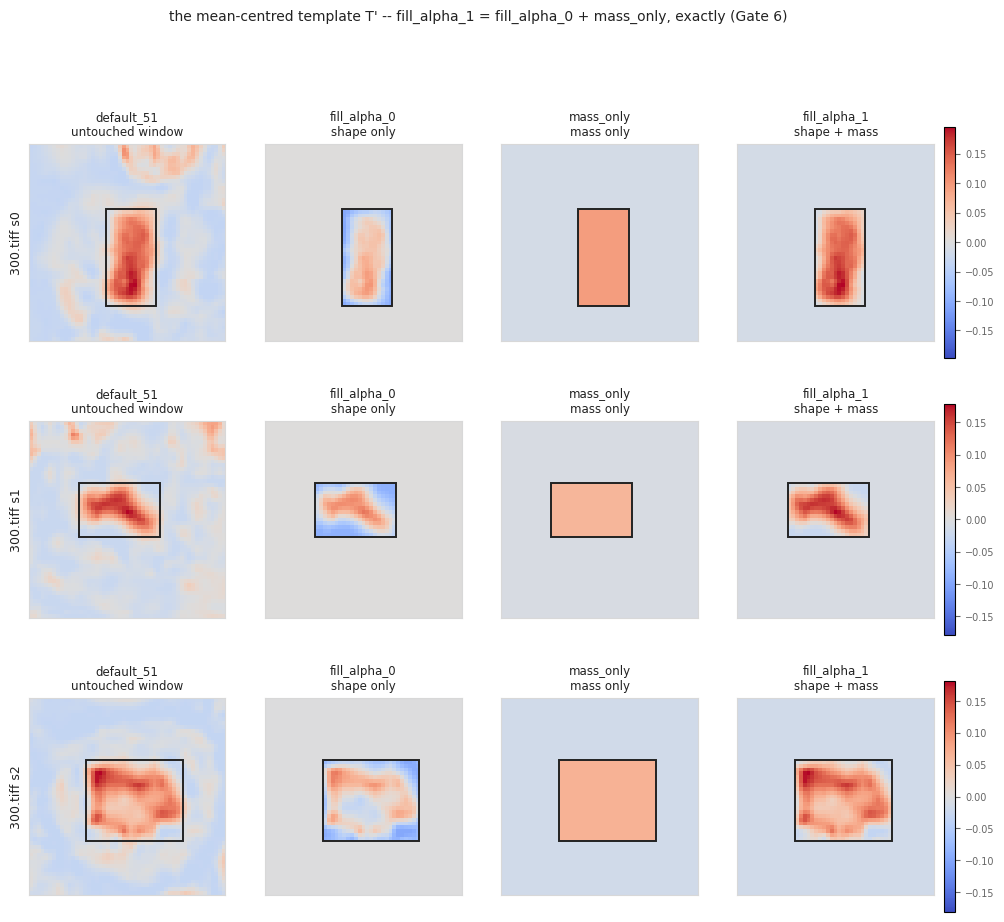

-> shapemass_inspect_templates.png


In [12]:
INK, MUTED, GRID = '#222222', '#666666', '#d8d8d8'


def recessive(ax):
    """
        Push an axes' frame and grid behind the data, the house style for every panel here.

        ax (matplotlib.axes.Axes): the axes to restyle.

        Returns None.
    """
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    ax.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)


# Figure 1 -- the four templates as T', the only thing TM_CCOEFF correlates. T' is signed around 0, so this is a
# diverging scale with a neutral midpoint and symmetric limits shared across a row. mass_only reads as two flat
# levels: all of its structure is the rectangle's outline, which is the point.
panel_clicks = [(INSPECT_ROI, s) for s in SEED_INDICES if (INSPECT_ROI, s) in CUTS] or list(CUTS)[:3]
fig, axes = plt.subplots(len(panel_clicks), len(ARMS), figsize=(3.0 * len(ARMS), 3.4 * len(panel_clicks)), squeeze=False)
for row, key in enumerate(panel_clicks):
    cut = CUTS[key]
    y0, y1, x0, x1 = cut['rect']
    primes = {arm: cut['templates'][arm].astype(np.float64) - cut['templates'][arm].astype(np.float64).mean() for arm in ARMS}
    vmax = max(float(np.abs(p).max()) for p in primes.values())
    for col, arm in enumerate(ARMS):
        ax = axes[row][col]
        im = ax.imshow(primes[arm], cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.add_patch(Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0, fill=False, edgecolor=INK, linewidth=1.4))
        ax.set_title(f'{arm}\n{ARM_TERMS[arm]}', fontsize=8.5, color=INK)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ax.spines.values():
            side.set_color(GRID)
    axes[row][0].set_ylabel(f'{key[0]} s{key[1]}', fontsize=9, color=INK)
    fig.colorbar(im, ax=axes[row], fraction=0.016, pad=0.01).ax.tick_params(colors=MUTED, labelsize=7)
fig.suptitle("the mean-centred template T' -- fill_alpha_1 = fill_alpha_0 + mass_only, exactly (Gate 6)", fontsize=10, color=INK, y=0.995)
fig.savefig(FIG_PATHS['inspect_templates'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['inspect_templates']}")

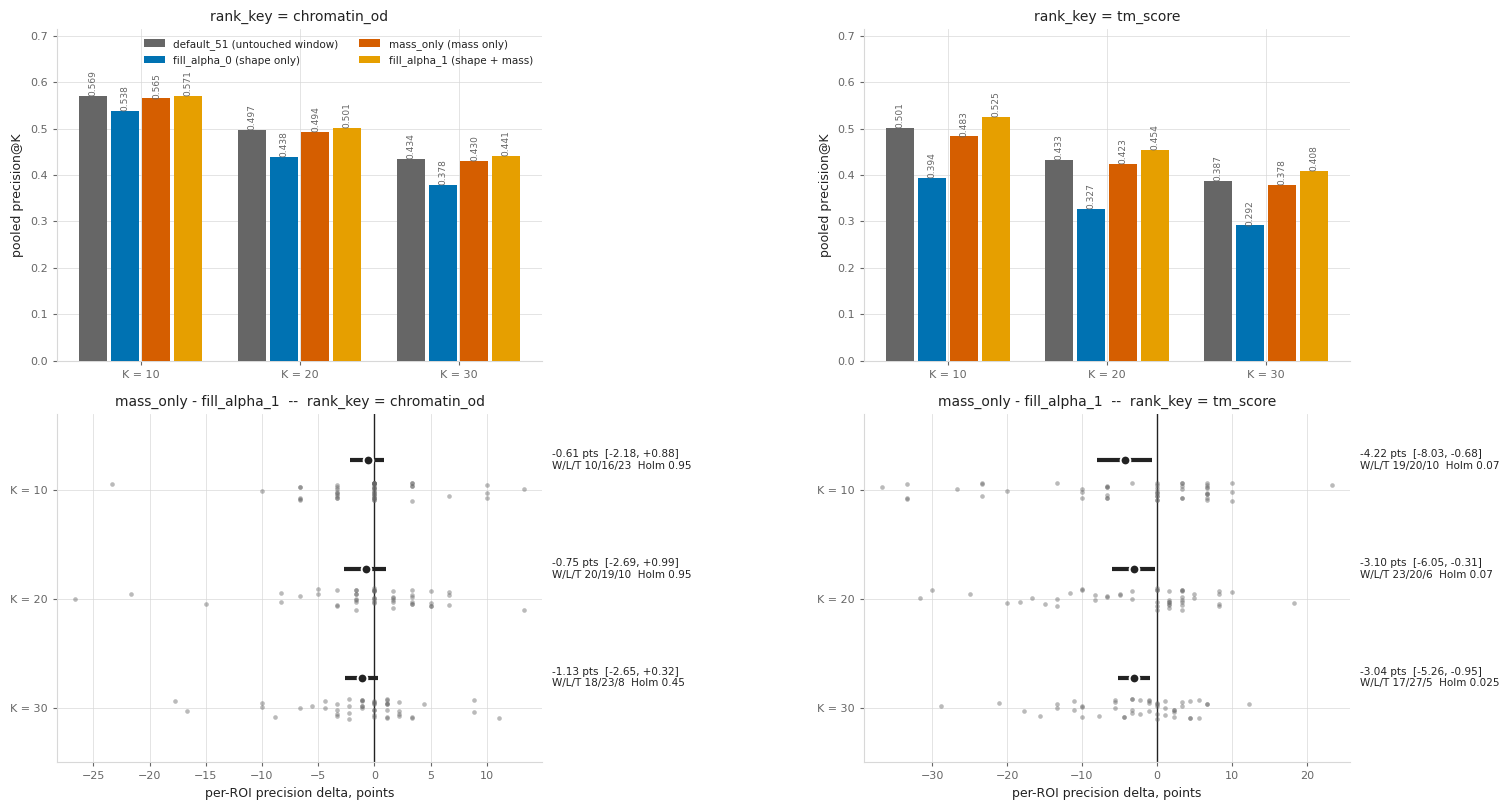

-> shapemass_precision.png

notebook total: 30.7 min


In [13]:
# Figure 2 -- the outcome, one column per ranking axis. Top: pooled precision per arm. Bottom: the primary
# contrast's per-ROI deltas with the pooled delta and its bootstrap CI. The annotations sit outside the axes so
# the x-limit can follow the data and the CI marks stay legible.
primary = f"{FAMILY_PAIRS['primary_3'][0][0]} - {FAMILY_PAIRS['primary_3'][0][1]}"
fig, axes = plt.subplots(2, len(AXES), figsize=(7.6 * len(AXES), 8.2), gridspec_kw=dict(height_ratios=[1, 1.05]))

width = 0.2
for col, axis in enumerate(AXES):
    ax = axes[0][col]
    for i, arm in enumerate(ARMS):
        v = [POOLED.loc[(POOLED['rank_key'] == axis) & (POOLED['condition'] == arm) & (POOLED['K'] == k), 'precision_pooled'].iat[0] for k in BUDGETS]
        xs = np.arange(len(BUDGETS)) + (i - (len(ARMS) - 1) / 2) * width
        ax.bar(xs, v, width=width * 0.88, color=ARM_COLOR[arm], label=f'{arm} ({ARM_TERMS[arm]})', zorder=3)
        for x, val in zip(xs, v):
            ax.text(x, val + 0.004, f'{val:.3f}', ha='center', fontsize=6.5, color=MUTED, rotation=90)
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'K = {k}' for k in BUDGETS], fontsize=9, color=INK)
    ax.set_ylabel('pooled precision@K', fontsize=9, color=INK)
    ax.set_ylim(0, POOLED['precision_pooled'].max() * 1.25)
    ax.set_title(f'rank_key = {axis}', fontsize=10, color=INK)
    if col == 0:
        ax.legend(fontsize=7.5, frameon=False, ncol=2, labelcolor=INK, loc='upper right')
    recessive(ax)

    ax = axes[1][col]
    spread = []
    for k in BUDGETS:
        st = DELTA_STATS[(DELTA_STATS['rank_key'] == axis) & (DELTA_STATS['pair'] == primary) & (DELTA_STATS['K'] == k)].iloc[0]
        spread += [100 * st['ci_low'], 100 * st['ci_high']] + list(100 * DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == primary) & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'] / (3 * k))
    lo, hi = min(spread), max(spread)
    for j, k in enumerate(BUDGETS):
        v = 100 * DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == primary) & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'].to_numpy() / (3 * k)
        st = DELTA_STATS[(DELTA_STATS['rank_key'] == axis) & (DELTA_STATS['pair'] == primary) & (DELTA_STATS['K'] == k)].iloc[0]
        ax.scatter(v, np.full(len(v), j) + np.random.default_rng(k).uniform(-0.1, 0.1, len(v)), s=11, color=MUTED, alpha=0.45, linewidths=0, zorder=3)
        ax.plot([100 * st['ci_low'], 100 * st['ci_high']], [j - 0.28, j - 0.28], color=INK, linewidth=3, solid_capstyle='butt', zorder=4)
        ax.plot([100 * st['pooled_delta_precision']], [j - 0.28], marker='o', ms=7, color=INK, markeredgecolor='white', markeredgewidth=1.4, zorder=5)
        ax.annotate(f"{100 * st['pooled_delta_precision']:+.2f} pts  [{100 * st['ci_low']:+.2f}, {100 * st['ci_high']:+.2f}]\nW/L/T {int(st['wins'])}/{int(st['losses'])}/{int(st['ties'])}  Holm {st['holm_p']:.2g}", xy=(1.02, j - 0.28), xycoords=('axes fraction', 'data'), fontsize=7.5, color=INK, va='center', ha='left', annotation_clip=False)
    ax.axvline(0, color=INK, linewidth=1.0, zorder=2)
    ax.set_yticks(range(len(BUDGETS)))
    ax.set_yticklabels([f'K = {k}' for k in BUDGETS], fontsize=9, color=INK)
    ax.set_xlabel('per-ROI precision delta, points', fontsize=9, color=INK)
    ax.set_xlim(lo - 0.04 * (hi - lo), hi + 0.04 * (hi - lo))
    ax.set_ylim(len(BUDGETS) - 0.5, -0.7)
    ax.set_title(f'{primary}  --  rank_key = {axis}', fontsize=10, color=INK)
    recessive(ax)

fig.tight_layout(w_pad=9.0)
fig.savefig(FIG_PATHS['precision'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['precision']}")
print(f'\nnotebook total: {(time.time() - NB_T0) / 60:.1f} min')

## Reading the result

**Outcome: the second pre-registered one.** `mass_only` ties `fill_alpha_1` at `chromatin_od` and loses at
`tm_score`, so the `chromatin_od` tie is the ranker-alignment confound the header warned about and the `tm_score`
row carries the inference. But the size matters as much as the sign: deleting the **shape** term costs 3 points,
while deleting the **mass** term costs 12. The template is overwhelmingly a mass detector with a small real
appearance term on top.

Pooled precision@K, 49 ROIs x 3 clicks:

| arm | terms | `chromatin_od` K=10/20/30 | `tm_score` K=10/20/30 |
|---|---|---|---|
| `default_51` | untouched window | 0.5694 / 0.4973 / 0.4340 | 0.5007 / 0.4330 / 0.3868 |
| `fill_alpha_0` | shape only | 0.5381 / 0.4381 / 0.3778 | 0.3939 / 0.3269 / 0.2916 |
| `mass_only` | **mass only** | 0.5646 / 0.4935 / 0.4297 | 0.4830 / 0.4235 / 0.3780 |
| `fill_alpha_1` | shape + mass | **0.5707 / 0.5010 / 0.4410** | **0.5252 / 0.4544 / 0.4084** |

### The primary contrast, `mass_only - fill_alpha_1`

**At `chromatin_od`, nothing resolves.** -0.61 pts [-2.18, +0.88] (t [-2.23, +1.01], W/L/T 10/16/23, 26 nonzero,
Holm 0.946) at K=10; -0.75 [-2.69, +0.99] (20/19/10, Holm 0.946) at K=20; -1.13 [-2.65, +0.32] (18/23/8,
Holm 0.454) at K=30. D5 is met nowhere. A two-level box filter is indistinguishable from the full template on
this axis, and the CIs bound the difference at roughly 2.7 points.

**At `tm_score`, it loses.** -4.22 pts [-8.03, -0.68] (t [-8.07, -0.37], W/L/T 19/20/10, 39 nonzero, exact p
0.035, Holm 0.070) at K=10; -3.10 [-6.05, -0.31] (23/20/6, Holm 0.070) at K=20; **-3.04 [-5.26, -0.95]**
(t [-5.29, -0.79], W/L/T 17/27/5, 44 nonzero, exact p 0.0084, **Holm 0.025, D5 bar met**) at K=30.

Note what D5 catches at K=10 and K=20: the bootstrap CI excludes 0 but wins and losses are nearly balanced
(19/20 and 23/20), so the pooled deficit is carried by a handful of ROIs with large negative deltas rather than by
a broad majority. Only K=30 has both the interval and the majority, and it is the only row of the three to clear
Holm. Quote K=30; treat K=10 and K=20 as directionally consistent but not resolved.

### The rest of the decomposition

**Mass beats shape, decisively, on both axes.** `mass_only - fill_alpha_0`: at `chromatin_od` +2.65 pts (ns),
+5.54 [+1.94, +8.98] (Holm 0.0097, D5 met) and +5.19 [+2.43, +7.87] (Holm 0.0025, D5 met); at `tm_score`
+8.91 [+3.40, +14.22], +9.66 [+5.24, +14.01] and +8.64 [+4.92, +12.40], every Holm <= 0.003 and D5 met at all
three K.

**Deleting mass costs four times what deleting shape costs.** `fill_alpha_0 - fill_alpha_1` is -3.27 / -6.29 /
-6.33 pts at `chromatin_od` (reproducing the recorded sweep exactly, as the gate required) and **-13.13 / -12.76 /
-11.68** at `tm_score`, every Holm <= 1.7e-08 with D5 met throughout. Against the primary's -3 to -4 points for
deleting shape, the asymmetry is the headline.

**`mass_only` equals `default_51` on both axes.** -0.48 / -0.37 / -0.43 at `chromatin_od` and -1.77 / -0.95 /
-0.88 at `tm_score`; every CI includes 0, every Holm is 1.0. A box filter built from nothing but the rectangle
matches the untouched 51 px window.

**New at `tm_score`: the fill earns its keep.** `fill_alpha_1 - default_51` is null at `chromatin_od` (as
recorded) but **+2.45 / +2.14 / +2.15** points at `tm_score`, CIs excluding 0 throughout, Holm 0.124 / 0.038 /
0.0088 and D5 met at K=30. Flattening the surround helps on the axis where candidate generation and ranking do
not share a statistic -- a result the `chromatin_od`-only measurements could not see.

### What this means

The click's template is doing two things, and they are wildly unequal in size. **Mass** -- how much extra
hematoxylin sits in a footprint of this size -- is nearly all of it: a two-level box filter recovers 92-93% of the
full template's precision at `tm_score` and is statistically indistinguishable from it at `chromatin_od`.
**Shape** -- whether the texture matches this particular cell -- adds a real but small increment, about 3 points,
visible only once the ranker stops sharing an axis with the mass term.

For the product that is the substantive finding: **the click is mostly supplying a footprint, not an appearance.**
Template-pixel refinement -- keep-region shape, hybrid rectangles, margins -- is tuning the 3-point term while the
12-point term is set by the rectangle's size alone.

### The finding that does not show up in any delta

**`mass_only` and `fill_alpha_1` share a median of 1 of 30 top-30 detections** -- on both axes -- while scoring
within about a point of each other at `chromatin_od`. Two almost entirely disjoint candidate lists achieve the
same hit rate. In a 2 mm^2 ROI holding 100-220 mitotic figures that is possible without contradiction: the arms
are finding *different* mitoses at similar rates.

That is a limit on what precision@K can settle here. Equal precision between near-disjoint lists does **not** make
two arms interchangeable for a pathologist working down a list: they surface different cells, so their coverage of
the ROI's mitotic population can differ even where their precision does not. Any decision that turns on "which
arm finds more of what is there" needs a recall or coverage measurement, not this one.

### Standing caveats

- The 147 clicks are the 49-ROI joint gate's, so every click is one where both Otsu gates accept and a kept
  rectangle exists by construction.
- One keep-region (the tight `tighten_box_otsu` rectangle, median 25x26 px, 22.6% of the window) and one channel.
- `mass_only` still takes its **footprint** from the clicked cell. This run shows the cell's *appearance* adds
  about 3 points; it does **not** show that the click is dispensable. Severing the footprint from the cell -- for
  instance re-using another click's rectangle on the same ROI, which holds the footprint distribution fixed -- is
  the next arm.
- `max_peaks` binds at 100 on 1176/1176 rows, so every arm is compared at a saturated pool.
- The two axes are two families, reported separately. They are not independent -- they rank the same detections --
  so a result on one is not a replication of the other.